In [112]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [113]:
data = pd.read_csv("../data/kenyan_online_shop_data.csv")

data.head()

,InvoiceNo,CustomerID,Product,Quantity,UnitPrice,TotalPrice,InvoiceDate,Location,CustomerType
0,ORD10000,CUST1076,Sanitary Towels (Pack),1,153.60,153.60,2/17/2023,Umoja,Regular
1,ORD10001,CUST1075,Bread (400g),1,52.55,52.55,2/9/2023,Nairobi,Regular
2,ORD10002,CUST1020,Milk (500ml),1,44.20,44.20,2/1/2023,Roysambu,Regular
3,ORD10003,CUST1181,Sanitary Towels (Pack),1,250.33,250.33,2/22/2023,Ruiru,Budget
4,ORD10004,CUST1079,Sugar (1kg),1,132.24,132.24,4/13/2023,Nairobi,Budget


In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InvoiceNo     1500 non-null   object 
 1   CustomerID    1500 non-null   object 
 2   Product       1500 non-null   object 
 3   Quantity      1500 non-null   int64  
 4   UnitPrice     1500 non-null   float64
 5   TotalPrice    1500 non-null   float64
 6   InvoiceDate   1500 non-null   object 
 7   Location      1500 non-null   object 
 8   CustomerType  1500 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 105.6+ KB


In [115]:
data.columns

Index(['InvoiceNo', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'TotalPrice', 'InvoiceDate', 'Location', 'CustomerType'],
      dtype='object')

In [116]:
data['InvoiceDate'] = pd.to_datetime(data['InvoiceDate'])
data['Month'] = data['InvoiceDate'].dt.month
data['Day'] = data['InvoiceDate'].dt.day

## Revenue by location:
 Analysis of total revenue varying in different locations to identify the most profitable location.

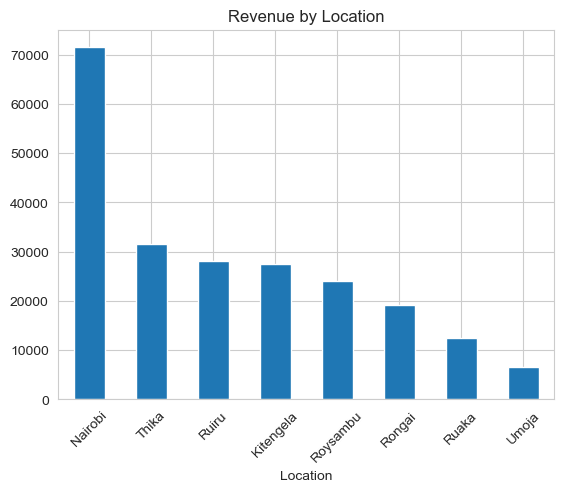

In [117]:
location_sales = data.groupby('Location')['TotalPrice'].sum().sort_values(ascending=False)

location_sales.plot(kind= 'bar')
plt.title("Revenue by Location")
plt.xticks(rotation = 45)
plt.show()

# Revenue by Location Insights
-Nairobi generates the highest revenue among all locations
-This indicates a strong customer base and higher purchasing activity in urban areas
-The lower revenue in other locations suggests untapped market potential
-The business could increase overall revenue by expanding marketing and distribution strategies in underperforming locations.

## Customer Spending analysis by Customer Type

-This analysis explores how different customer segments contribute to overall revenue.
-The objective is to identify high-value customer segments and understand spending patterns.

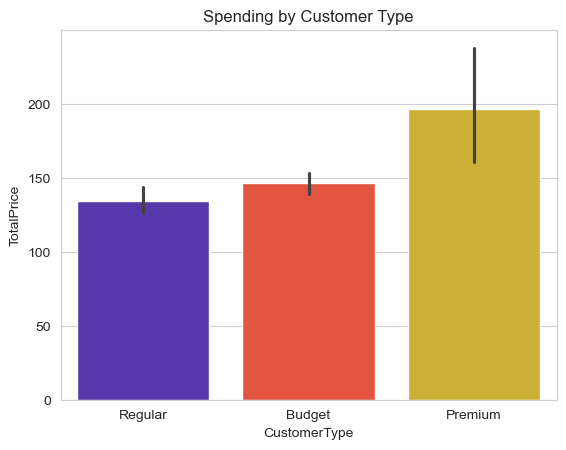

In [118]:
sns.barplot(data=data, x=("CustomerType"), y=("TotalPrice"), hue=("CustomerType"), palette="CMRmap", legend=False)
plt.title("Spending by Customer Type")
plt.show()

# Customer segmentation Insights
- Premium customers spend the most on average.
- Budget customers show moderate spending, slightly higher than Regular customers, indicating potential for upselling.
- Regular customers have the lowest average spending, suggesting they may be more price sensitive.
- The variation (error bars) is highest among Premium customers, meaning their spending is less consistent but can reach very high values.

# Customer Business Implications
- Focus marketing efforts on retaining Premium customers, as they drive the most revenue.
- Develop strategies to convert Regular customers into higher-spending segments.
- Target Budget customers with personalized offers to increase their average purchase value.

## Monthly Revenue Trend
This visualization shows the total monthly revenue generated over the year.
It helps identify patterns, seasonality and fluctuations in sales performance across different months.

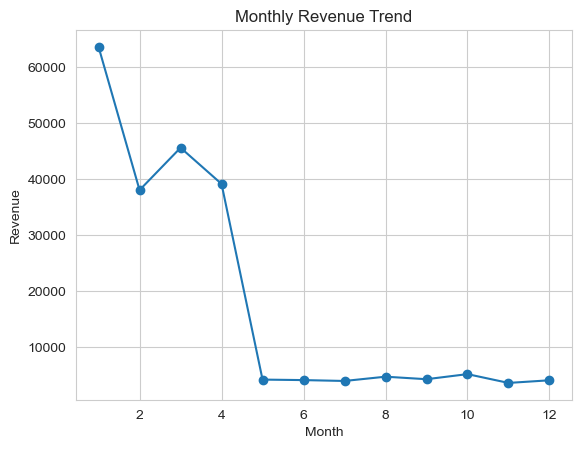

In [119]:
monthly_sales = data.groupby('Month')['TotalPrice'].sum()

monthly_sales.plot(marker= 'o')
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# Revenue Trend Insights
- Revenue is highest at the beginning of the year, with a peak in month 1.
- There is a sharp decline after month 4, indicating a significant drop in sales activity.
- From month5 onward, revenue remains consistently low with minor fluctuations.

# Revenue Business Implications
- The early months may represent ahigh demand season or promotional period.
- The sharp drop suggests a need to investigate potential causes such as reduced demand or low marketing.
- Strategies like seasonal promotions or customer retention campaigns could help stabilize revenue throughout the year.

# Top Selling Products 
Analysis objective is to determine which products drive the highest sales volume and obtain the demand trends.

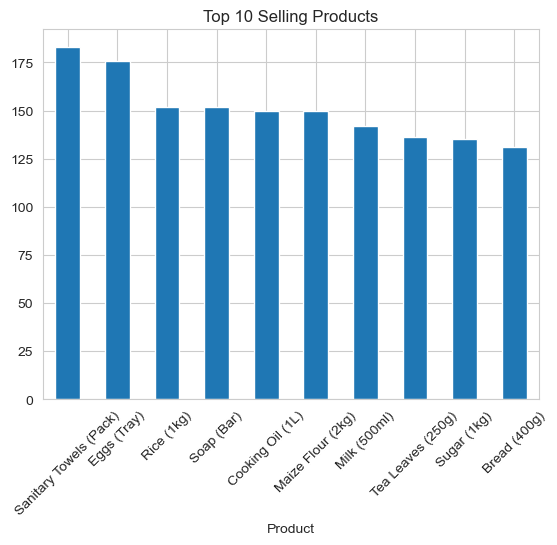

In [120]:
top_products = data.groupby('Product')['Quantity'].sum().sort_values(ascending=False)

top_products.plot(kind='bar')
plt.title("Top 10 Selling Products")
plt.xticks(rotation=45)
plt.show()

# Product Insights
- Fast moving consumer goods dominance with sanitary towels ranking followed by eggs.
- Consistent demand.

# Product Implications
- Prioritize high turnover and 'Just-in-Time' inventory for perishables to minimize waste
- Implement product bundling to increase average order value.

# Price vs Quantity

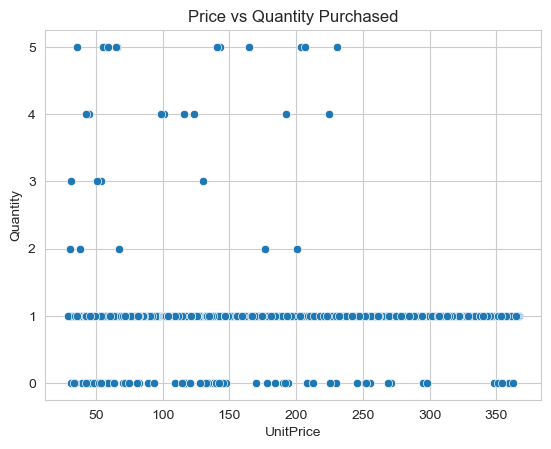

In [121]:
sns.scatterplot(data=data, x="UnitPrice", y="Quantity")
plt.title("Price vs Quantity Purchased")
plt.show()

# Pricing & Quantity Insights
- There is a high concentration of transactions at lower unit prices, where customers are likely to purchase multiple units.
- As the UnitPrice increases,the transaction volume shifts almost exclusively toward single-unit purchases.

# Pricing & Quantity Business Implications
- Since higher-priced items are rarely bought in bulk, implementig "Buy 2 get 1" or tiered discounts on mid-range items could help push quantity levels higher.
- Low-cost items require high stock levels to support bulk buying, whereas high-value items can be managed with leaner inventory.